In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

from numpy.random import Generator as RNGGenerator, default_rng
from scipy.interpolate import RBFInterpolator
from scipy.optimize import differential_evolution
from scipy.special import expit, logit

from sympleq.applications.randomized_benchmarking.RMB import RMB
from sympleq.applications.randomized_benchmarking.backends import SympleqBackend
from sympleq.applications.randomized_benchmarking.config import RMBConfig, RMBData
from sympleq.core.bayesian_estimation import BayesianEstimator
from sympleq.core.noise.noise_model import GenericNoise

In [2]:
@dataclass(frozen=True)
class OptimizationSettings:
    n_qubits: int = 10
    random_elimination: float = 0.25
    scrambling_probability: float = 0.5
    one_q_bounds: tuple[int, int] = (500, 1000)
    two_q_bounds: tuple[int, int] = (0, 500)
    target_threshold: float = 0.5
    initial_random_samples: int = 10
    optimization_steps: int = 30
    shots_per_step: int = 2
    max_shots_per_config: int = 8
    min_fit_points: int = 8
    surface_smoothing: float = 0.05
    optimizer_maxiter: int = 120
    optimizer_popsize: int = 10
    optimizer_restarts: int = 2
    random_candidate_pool: int = 96
    exploration_weight: float = 0.30
    diversity_radius: float = 0.18
    reference_one_q_points: int = 6
    reference_two_q_points: int = 6
    reference_shots_per_config: int = 2
    plot_grid_size: int = 300
    rng_seed: int = 0


SETTINGS = OptimizationSettings()

SINGLE_Q_PAULI_ERROR = 0.000025
TWO_Q_PAULI_ERROR = 0.00079

In [3]:
def make_sympleq_backend() -> SympleqBackend:
    return SympleqBackend(
        noise_model=GenericNoise.from_paulis([SINGLE_Q_PAULI_ERROR] * 3),
        two_qubit_noise_model=GenericNoise.from_paulis([TWO_Q_PAULI_ERROR] * 3),
    )


def rounded_gate_counts(
    one_q_gates: float,
    two_q_gates: float,
    settings: OptimizationSettings,
    *,
    clip: bool = True,
 ) -> tuple[int, int]:
    one_q = float(one_q_gates)
    two_q = float(two_q_gates)
    if clip:
        one_q = float(np.clip(one_q, settings.one_q_bounds[0], settings.one_q_bounds[1]))
        two_q = float(np.clip(two_q, settings.two_q_bounds[0], settings.two_q_bounds[1]))
    one_q_int = max(2 * settings.n_qubits, int(round(one_q)))
    two_q_int = max(0, int(round(two_q)))
    return one_q_int, two_q_int


def config_from_gate_counts(
    one_q_gates: float,
    two_q_gates: float,
    settings: OptimizationSettings,
 ) -> RMBConfig:
    one_q, two_q = rounded_gate_counts(one_q_gates, two_q_gates, settings)
    return (
        RMBConfig.default()
        .with_n_qubits(settings.n_qubits)
        .with_random_elimination(settings.random_elimination)
        .with_scrambling_probability(settings.scrambling_probability)
        .with_n_1qb_gates(one_q)
        .with_n_2qb_gates(two_q)
    )


def estimator_for(data: RMBData, config: RMBConfig) -> BayesianEstimator:
    return data.setdefault(config, BayesianEstimator(threshold=0.0, min_runs=0))


def fidelity_mean(estimator: BayesianEstimator) -> float:
    counts = estimator.counts()
    true_count = counts.get(True, 0)
    false_count = counts.get(False, 0)
    return (true_count + 1.0) / (true_count + false_count + 2.0)


def fidelity_variance(estimator: BayesianEstimator) -> float:
    counts = estimator.counts()
    true_count = counts.get(True, 0)
    false_count = counts.get(False, 0)
    alpha = true_count + 1.0
    beta = false_count + 1.0
    total = alpha + beta
    return alpha * beta / (total * total * (total + 1.0))


def spend_measurements(
    backend: SympleqBackend,
    rng: RNGGenerator,
    data: RMBData,
    config: RMBConfig,
    n_measurements: int,
 ) -> int:
    estimator = estimator_for(data, config)
    spent = 0

    while spent < n_measurements:
        outcomes = backend.fidelity_estimation(config, rng)
        for _, passed in outcomes:
            if spent >= n_measurements:
                break
            estimator.record(bool(passed))
            spent += 1

    return spent


def total_measurements(data: RMBData) -> int:
    return sum(estimator.num_runs() for estimator in data.values())

In [4]:
@dataclass
class FidelitySurface:
    interpolator: RBFInterpolator
    one_q_bounds: tuple[int, int]
    two_q_bounds: tuple[int, int]

    def _scale(self, points: np.ndarray) -> np.ndarray:
        points = np.asarray(points, dtype=float)
        lower = np.array([self.one_q_bounds[0], self.two_q_bounds[0]], dtype=float)
        upper = np.array([self.one_q_bounds[1], self.two_q_bounds[1]], dtype=float)
        return np.clip((points - lower) / (upper - lower), 0.0, 1.0)

    def probability(self, points: np.ndarray) -> np.ndarray:
        logits = np.asarray(self.interpolator(self._scale(points))).reshape(-1)
        return np.clip(expit(logits), 1e-4, 1.0 - 1e-4)


def scaled_point(
    one_q_gates: float,
    two_q_gates: float,
    settings: OptimizationSettings,
 ) -> np.ndarray:
    lower = np.array([settings.one_q_bounds[0], settings.two_q_bounds[0]], dtype=float)
    upper = np.array([settings.one_q_bounds[1], settings.two_q_bounds[1]], dtype=float)
    point = np.array([one_q_gates, two_q_gates], dtype=float)
    return np.clip((point - lower) / (upper - lower), 0.0, 1.0)


def observed_points(data: RMBData, settings: OptimizationSettings) -> np.ndarray:
    points = [
        scaled_point(
            float(config.n_1qb_gates),
            float(config.n_2qb_gates),
            settings,
        )
        for config, estimator in data.items()
        if estimator.num_runs() > 0
    ]
    if not points:
        return np.empty((0, 2), dtype=float)
    return np.asarray(points, dtype=float)


def nearest_distance(point: np.ndarray, points: np.ndarray) -> float:
    if len(points) == 0:
        return 1.0
    distances = np.linalg.norm(points - point, axis=1)
    return float(np.min(distances))


def contour_target(settings: OptimizationSettings) -> float:
    target = float(settings.target_threshold)
    if not 0.0 <= target <= 1.0:
        raise ValueError(f"target_threshold must be within [0, 1], got {target}.")
    return target


def contour_alignment(probability: float, settings: OptimizationSettings) -> float:
    target = contour_target(settings)
    max_distance = max(target, 1.0 - target)
    if max_distance == 0.0:
        return 1.0
    normalized_error = abs(probability - target) / max_distance
    return float(np.clip(1.0 - normalized_error, 0.0, 1.0))


def fit_fidelity_surface(
    data: RMBData,
    settings: OptimizationSettings,
 ) -> FidelitySurface:
    points = []
    values = []

    for config, estimator in data.items():
        if estimator.num_runs() == 0:
            continue
        points.append([float(config.n_1qb_gates), float(config.n_2qb_gates)])
        values.append(fidelity_mean(estimator))

    if len(points) < settings.min_fit_points:
        raise ValueError(
            f"Need at least {settings.min_fit_points} measured configs for a smooth fit, got {len(points)}."
        )

    points_array = np.asarray(points, dtype=float)
    values_array = np.clip(np.asarray(values, dtype=float), 1e-4, 1.0 - 1e-4)
    lower = np.array([settings.one_q_bounds[0], settings.two_q_bounds[0]], dtype=float)
    upper = np.array([settings.one_q_bounds[1], settings.two_q_bounds[1]], dtype=float)
    scaled_points = np.clip((points_array - lower) / (upper - lower), 0.0, 1.0)

    interpolator = RBFInterpolator(
        scaled_points,
        logit(values_array),
        kernel="thin_plate_spline",
        degree=1,
        smoothing=settings.surface_smoothing,
    )
    return FidelitySurface(
        interpolator=interpolator,
        one_q_bounds=settings.one_q_bounds,
        two_q_bounds=settings.two_q_bounds,
    )


def sample_random_config(
    settings: OptimizationSettings,
    rng: RNGGenerator,
    data: RMBData | None = None,
 ) -> RMBConfig:
    for _ in range(128):
        one_q = int(rng.integers(settings.one_q_bounds[0], settings.one_q_bounds[1] + 1))
        two_q = int(rng.integers(settings.two_q_bounds[0], settings.two_q_bounds[1] + 1))
        config = config_from_gate_counts(one_q, two_q, settings)
        if data is None or config not in data:
            return config
    return config


def acquisition_score(
    theta: np.ndarray,
    surface: FidelitySurface,
    data: RMBData,
    settings: OptimizationSettings,
 ) -> float:
    one_q, two_q = rounded_gate_counts(theta[0], theta[1], settings)
    probability = float(surface.probability(np.array([[one_q, two_q]], dtype=float))[0])
    alignment = contour_alignment(probability, settings)
    point = scaled_point(float(one_q), float(two_q), settings)
    sparsity = min(1.0, nearest_distance(point, observed_points(data, settings)) / settings.diversity_radius)
    config = config_from_gate_counts(one_q, two_q, settings)
    current_runs = data[config].num_runs() if config in data else 0
    if current_runs >= settings.max_shots_per_config:
        return 0.0
    undersampled = 1.0 - current_runs / max(1, settings.max_shots_per_config)
    return float(alignment * (1.0 + settings.exploration_weight * sparsity) * undersampled)


def propose_next_config(
    data: RMBData,
    settings: OptimizationSettings,
    rng: RNGGenerator,
 ) -> RMBConfig:
    try:
        surface = fit_fidelity_surface(data, settings)
    except ValueError:
        return sample_random_config(settings, rng, data)

    bounds = [settings.one_q_bounds, settings.two_q_bounds]

    def objective(theta: np.ndarray) -> float:
        return -acquisition_score(theta, surface, data, settings)

    best_config: RMBConfig | None = None
    best_score = -np.inf

    for _ in range(settings.optimizer_restarts):
        seed = int(rng.integers(0, np.iinfo(np.int32).max))
        result = differential_evolution(
            objective,
            bounds=bounds,
            seed=seed,
            maxiter=settings.optimizer_maxiter,
            popsize=settings.optimizer_popsize,
            polish=True,
            updating="immediate",
            workers=1,
        )
        config = config_from_gate_counts(float(result.x[0]), float(result.x[1]), settings)
        score = acquisition_score(
            np.array([float(config.n_1qb_gates), float(config.n_2qb_gates)], dtype=float),
            surface,
            data,
            settings,
        )
        if score > best_score:
            best_score = score
            best_config = config

    candidate_pool = []
    if best_config is not None:
        candidate_pool.append(best_config)
    for _ in range(settings.random_candidate_pool):
        candidate_pool.append(sample_random_config(settings, rng))

    unique_candidates = []
    seen = set()
    for config in candidate_pool:
        if config in seen:
            continue
        seen.add(config)
        if config in data and data[config].num_runs() >= settings.max_shots_per_config:
            continue
        unique_candidates.append(config)

    if not unique_candidates:
        return sample_random_config(settings, rng)

    return max(
        unique_candidates,
        key=lambda config: acquisition_score(
            np.array([float(config.n_1qb_gates), float(config.n_2qb_gates)], dtype=float),
            surface,
            data,
            settings,
        ),
    )

In [5]:
def closest_measured_config(
    data: RMBData,
    settings: OptimizationSettings,
) -> tuple[RMBConfig, float, float]:
    target = contour_target(settings)
    measured = [
        (config, fidelity_mean(estimator), fidelity_variance(estimator))
        for config, estimator in data.items()
        if estimator.num_runs() > 0
    ]
    if not measured:
        raise ValueError("No measurements have been recorded yet.")
    return min(
        measured,
        key=lambda item: (abs(item[1] - target), item[2], -item[1]),
    )


def run_optimization(settings: OptimizationSettings):
    target = contour_target(settings)
    rng = default_rng(settings.rng_seed)
    backend = make_sympleq_backend()
    rmb = RMB.default(rng).with_backend(backend)
    data: RMBData = rmb._data
    results = []

    total_trials = settings.initial_random_samples + settings.optimization_steps
    for trial in range(total_trials):
        phase = "init" if trial < settings.initial_random_samples else "opt"
        if phase == "init":
            config = sample_random_config(settings, rng, data)
        else:
            config = propose_next_config(data, settings, rng)

        spent = spend_measurements(
            backend=backend,
            rng=rng,
            data=data,
            config=config,
            n_measurements=settings.shots_per_step,
        )
        estimator = data[config]
        current_mean = float(fidelity_mean(estimator))
        current_error = abs(current_mean - target)
        closest_config, closest_mean, _ = closest_measured_config(data, settings)
        closest_error = abs(closest_mean - target)
        result = {
            "trial": trial,
            "phase": phase,
            "one_q_gates": config.n_1qb_gates,
            "two_q_gates": config.n_2qb_gates,
            "shots_added": spent,
            "total_shots": estimator.num_runs(),
            "mean_fidelity": current_mean,
            "threshold_error": float(current_error),
            "variance": float(fidelity_variance(estimator)),
            "closest_error_so_far": float(closest_error),
            "closest_one_q_gates": int(closest_config.n_1qb_gates),
            "closest_two_q_gates": int(closest_config.n_2qb_gates),
        }
        results.append(result)
        print(
            f"[{phase:4s}] trial {trial:3d}  1Q={config.n_1qb_gates:4d}  "
            f"2Q={config.n_2qb_gates:4d}  mean={result['mean_fidelity']:.3f}  "
            f"error={result['threshold_error']:.3f}  var={result['variance']:.4f}  "
            f"total_shots={result['total_shots']}"
        )

    closest_config, closest_mean, closest_variance = closest_measured_config(data, settings)
    closest_error = abs(closest_mean - target)
    print(
        f"\nClosest observed config to target={target:.3f}: 1Q={closest_config.n_1qb_gates}, "
        f"2Q={closest_config.n_2qb_gates}, mean={closest_mean:.3f}, "
        f"error={closest_error:.3f}, variance={closest_variance:.4f}, "
        f"total_measurements={total_measurements(data)}"
    )
    return rmb, results

In [6]:
def plot_optimization_results(
    rmb: RMB,
    results: list[dict[str, int | float | str]],
    settings: OptimizationSettings,
 ) -> None:
    data = rmb._data
    target = contour_target(settings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    plotted_surface = False
    try:
        surface = fit_fidelity_surface(data, settings)
        n = 80
        one_q_axis = np.linspace(settings.one_q_bounds[0], settings.one_q_bounds[1], n)
        two_q_axis = np.linspace(settings.two_q_bounds[0], settings.two_q_bounds[1], n)
        one_q_grid, two_q_grid = np.meshgrid(one_q_axis, two_q_axis)
        grid = np.column_stack([one_q_grid.ravel(), two_q_grid.ravel()])
        probability_grid = surface.probability(grid).reshape(n, n)
        heatmap = axes[0].contourf(
            one_q_grid,
            two_q_grid,
            probability_grid,
            levels=np.linspace(0.0, 1.0, 16),
            cmap="RdYlGn",
        )
        axes[0].contour(
            one_q_grid,
            two_q_grid,
            probability_grid,
            levels=[target],
            colors="black",
            linewidths=1.5,
        )
        plt.colorbar(heatmap, ax=axes[0], label="Fitted mean fidelity")
        plotted_surface = True
    except ValueError:
        pass

    configs = [config for config, estimator in data.items() if estimator.num_runs() > 0]
    means = np.array([fidelity_mean(data[config]) for config in configs], dtype=float)
    scatter = axes[0].scatter(
        [config.n_1qb_gates for config in configs],
        [config.n_2qb_gates for config in configs],
        c=means,
        cmap="RdYlGn",
        vmin=0.0,
        vmax=1.0,
        s=75,
        edgecolors="black",
        linewidths=0.5,
        zorder=5,
    )
    if not plotted_surface:
        plt.colorbar(scatter, ax=axes[0], label="Observed mean fidelity")

    closest_config, closest_mean, _ = closest_measured_config(data, settings)
    closest_error = abs(closest_mean - target)
    axes[0].scatter(
        [closest_config.n_1qb_gates],
        [closest_config.n_2qb_gates],
        marker="*",
        c="gold",
        edgecolors="black",
        s=240,
        label=f"Closest to target, |p-t|={closest_error:.3f}",
        zorder=6,
    )
    axes[0].set_xlabel("Number of 1Q gates")
    axes[0].set_ylabel("Number of 2Q gates")
    axes[0].set_title(f"Noisy RMB threshold-search landscape (target p={target:.3f})")
    axes[0].legend(loc="best")

    trials = np.array([row["trial"] for row in results], dtype=int)
    measured_errors = np.array([row["threshold_error"] for row in results], dtype=float)
    best_so_far = np.array([row["closest_error_so_far"] for row in results], dtype=float)
    init_mask = np.array([row["phase"] == "init" for row in results], dtype=bool)
    opt_mask = np.logical_not(init_mask)

    axes[1].scatter(
        trials[init_mask],
        measured_errors[init_mask],
        c="deepskyblue",
        s=45,
        label="Random init",
    )
    axes[1].scatter(
        trials[opt_mask],
        measured_errors[opt_mask],
        c="black",
        s=45,
        label="Adaptive selection",
    )
    axes[1].plot(
        trials,
        best_so_far,
        color="crimson",
        linewidth=2,
        label="Smallest error so far",
    )
    axes[1].set_xlabel("Trial")
    axes[1].set_ylabel("Absolute error to target threshold")
    axes[1].set_ylim(0.0, 1.05)
    axes[1].set_title(
        f"{len(results)} trials, {total_measurements(data)} total noisy RMB outcomes\n"
        f"Closest config to p={target:.2f}: 1Q={closest_config.n_1qb_gates}, 2Q={closest_config.n_2qb_gates}"
    )
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [7]:
def surface_probability_grid(
    surface: FidelitySurface,
    settings: OptimizationSettings,
 ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = settings.plot_grid_size
    one_q_axis = np.linspace(settings.one_q_bounds[0], settings.one_q_bounds[1], n)
    two_q_axis = np.linspace(settings.two_q_bounds[0], settings.two_q_bounds[1], n)
    one_q_grid, two_q_grid = np.meshgrid(one_q_axis, two_q_axis)
    grid = np.column_stack([one_q_grid.ravel(), two_q_grid.ravel()])
    probability_grid = surface.probability(grid).reshape(n, n)
    return one_q_grid, two_q_grid, probability_grid


def build_reference_data(settings: OptimizationSettings) -> RMBData:
    backend = make_sympleq_backend()
    rng = default_rng(settings.rng_seed + 10_000)
    data: RMBData = {}

    one_q_axis = np.linspace(
        settings.one_q_bounds[0],
        settings.one_q_bounds[1],
        settings.reference_one_q_points,
    )
    two_q_axis = np.linspace(
        settings.two_q_bounds[0],
        settings.two_q_bounds[1],
        settings.reference_two_q_points,
    )

    total_configs = len(one_q_axis) * len(two_q_axis)
    print(
        f"Reference sweep: {total_configs} configs x "
        f"{settings.reference_shots_per_config} shots each."
    )

    for one_q in one_q_axis:
        for two_q in two_q_axis:
            config = config_from_gate_counts(one_q, two_q, settings)
            spend_measurements(
                backend=backend,
                rng=rng,
                data=data,
                config=config,
                n_measurements=settings.reference_shots_per_config,
            )

    return data


def plot_comparison_results(
    rmb: RMB,
    results: list[dict[str, int | float | str]],
    reference_data: RMBData,
    settings: OptimizationSettings,
 ) -> None:
    data = rmb._data
    target = contour_target(settings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    levels = np.linspace(0.0, 1.0, 25)

    reference_surface = fit_fidelity_surface(reference_data, settings)
    one_q_grid, two_q_grid, reference_grid = surface_probability_grid(reference_surface, settings)
    reference_map = axes[0].contourf(
        one_q_grid,
        two_q_grid,
        reference_grid,
        levels=levels,
        cmap="RdYlGn",
    )
    axes[0].contour(
        one_q_grid,
        two_q_grid,
        reference_grid,
        levels=[target],
        colors="black",
        linewidths=2,
    )
    plt.colorbar(reference_map, ax=axes[0], label="Reference mean fidelity")
    reference_configs = [
        config
        for config, estimator in reference_data.items()
        if estimator.num_runs() > 0
    ]
    axes[0].scatter(
        [config.n_1qb_gates for config in reference_configs],
        [config.n_2qb_gates for config in reference_configs],
        c="white",
        edgecolors="black",
        marker="s",
        s=28,
        linewidths=0.5,
        label="Reference sweep",
        zorder=5,
    )
    axes[0].set_xlabel("Number of 1Q gates")
    axes[0].set_ylabel("Number of 2Q gates")
    axes[0].set_title(
        f"Reference RMB fidelity surface (target p={target:.3f})\n"
        f"{len(reference_configs)} sweep configs, {settings.reference_shots_per_config} shots each"
    )
    axes[0].legend(loc="upper right", fontsize=8)

    learned_surface = fit_fidelity_surface(data, settings)
    one_q_grid, two_q_grid, learned_grid = surface_probability_grid(learned_surface, settings)
    learned_map = axes[1].contourf(
        one_q_grid,
        two_q_grid,
        learned_grid,
        levels=levels,
        cmap="RdYlGn",
    )
    axes[1].contour(
        one_q_grid,
        two_q_grid,
        learned_grid,
        levels=[target],
        colors="black",
        linewidths=2,
    )
    plt.colorbar(learned_map, ax=axes[1], label="Learned mean fidelity")

    init_pts = [row for row in results if row["phase"] == "init"]
    opt_pts = [row for row in results if row["phase"] == "opt"]
    axes[1].scatter(
        [row["one_q_gates"] for row in init_pts],
        [row["two_q_gates"] for row in init_pts],
        c="royalblue",
        marker="o",
        s=34,
        label="Random init",
        zorder=5,
        alpha=0.8,
    )
    axes[1].scatter(
        [row["one_q_gates"] for row in opt_pts],
        [row["two_q_gates"] for row in opt_pts],
        c="white",
        edgecolors="black",
        marker="^",
        s=42,
        label="Adaptive selection",
        zorder=6,
        alpha=0.95,
    )

    closest_config, closest_mean, _ = closest_measured_config(data, settings)
    closest_error = abs(closest_mean - target)
    axes[1].scatter(
        [closest_config.n_1qb_gates],
        [closest_config.n_2qb_gates],
        marker="*",
        c="gold",
        edgecolors="black",
        s=220,
        label=f"Closest observed, |p-t|={closest_error:.3f}",
        zorder=7,
    )
    axes[1].set_xlabel("Number of 1Q gates")
    axes[1].set_ylabel("Number of 2Q gates")
    axes[1].set_title(
        f"Adaptive RMB surrogate mean (black line = estimated p={target:.3f} contour)\n"
        f"{settings.initial_random_samples} random + {settings.optimization_steps} adaptive = {len(results)} total trials"
    )
    axes[1].legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

Using run settings: OptimizationSettings(n_qubits=5, random_elimination=0.25, scrambling_probability=0.5, one_q_bounds=(500, 1000), two_q_bounds=(0, 500), target_threshold=0.5, initial_random_samples=10, optimization_steps=100, shots_per_step=2, max_shots_per_config=8, min_fit_points=8, surface_smoothing=0.05, optimizer_maxiter=120, optimizer_popsize=10, optimizer_restarts=2, random_candidate_pool=96, exploration_weight=0.3, diversity_radius=0.18, reference_one_q_points=5, reference_two_q_points=5, reference_shots_per_config=5, plot_grid_size=300, rng_seed=0)
Reference sweep: 25 configs x 5 shots each.
[init] trial   0  1Q= 926  2Q= 319  mean=0.250  error=0.250  var=0.0375  total_shots=2
[init] trial   1  1Q= 821  2Q=  30  mean=0.500  error=0.000  var=0.0500  total_shots=2
[init] trial   2  1Q= 887  2Q= 233  mean=0.750  error=0.250  var=0.0375  total_shots=2
[init] trial   3  1Q= 685  2Q= 200  mean=0.750  error=0.250  var=0.0375  total_shots=2
[init] trial   4  1Q= 670  2Q= 100  mean=0

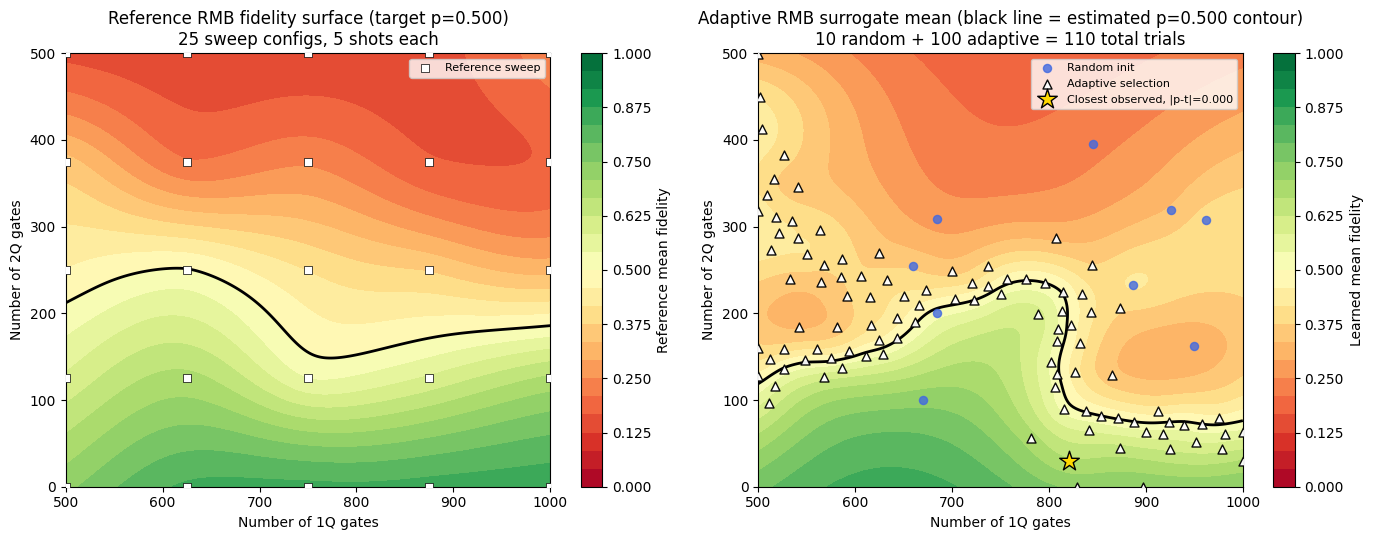

In [9]:
from dataclasses import replace

RUN_SETTINGS = replace(
    SETTINGS,
    n_qubits=5,
    target_threshold=0.5,
    initial_random_samples=10,
    optimization_steps=100,
    shots_per_step=2,
    max_shots_per_config=8,
    min_fit_points=8,
    surface_smoothing=0.05,
    optimizer_maxiter=120,
    optimizer_popsize=10,
    optimizer_restarts=2,
    random_candidate_pool=96,
    exploration_weight=0.30,
    diversity_radius=0.18,
    reference_one_q_points=5,
    reference_two_q_points=5,
    reference_shots_per_config=5,
    plot_grid_size=300,
    rng_seed=0,
)

print("Using run settings:", RUN_SETTINGS)
reference_data = build_reference_data(RUN_SETTINGS)
rmb, results = run_optimization(RUN_SETTINGS)
plot_comparison_results(rmb, results, reference_data, RUN_SETTINGS)